# 06. 단일세포(scRNA) 분석 — 과정 walkthrough (Python 근사)

**데이터**: GSE209781 (말기 DKD 신장, Control 3 + Late DKD 3), 실제 10x raw

> ⚠ **이 노트북은 Seurat 파이프라인을 Python(numpy)으로 '유사 재현'** 한 학습용 walkthrough입니다.
> R 전용 부분(Harmony·Leiden·UMAP·monocle)은 **가벼운 대체**(배치 평균보정·KMeans·PCA·손상점수 정렬)로 흉내냈고,
> 마커도 **32개 패널만** 씁니다. 따라서 **여기 수치는 근사이며 결론의 근거가 아닙니다.**
>
> ⭐ **최종·정식 결과는 R 파이프라인(`06_scrna/01~05.R`)입니다.** 그 결과 요약:
> - ✅ **말기 dPCT에서 ALDH2↓ 재현** (PCT 1.75 → dPCT 1.27, p=3e-85 · Fig 7G)
> - ⚠ **FN1은 세뇨관 snRNA에서 검출한계 이하**라 방향 확인 불가 (데이터 한계)
>
> 아래 Python 근사에선 FN1이 감소해 보이거나 ALDH2 dPCT가 거꾸로 나오기도 하는데,
> 이는 **간이 클러스터링·소수 패널의 잡음**일 뿐 신뢰하면 안 됩니다. 방향 판정은 R을 따르세요.

흐름: **QC → 정규화 → PCA → 배치보정 → 클러스터링 → 세포주석 → FN1/ALDH2 → 비율 → 유사시간**


## 0. QC 통과 세포 불러오기
raw 10x(배럴코드 679만, 대부분 빈 방울)에서 **QC(유전자 300~5000·미토<10%)** 로 진짜 세포만 남긴 결과를 불러옵니다.  
(무거운 raw 처리는 미리 수행 — `sc_proc.py`)


In [1]:
import numpy as np, matplotlib.pyplot as plt
np.random.seed(0)
CACHE='sc_cache'  # 노트북 폴더 내 영구 캐시 (npz 6개 동봉)
samples=[('NM01','Control'),('NM02','Control'),('NM03','Control'),
         ('DKD01','Late_DKD'),('DKD02','Late_DKD'),('DKD03','Late_DKD')]
mats=[]; grp=[]; smp=[]; qc=[]
panel=None
for s,g in samples:
    d=np.load(f'{CACHE}/{s}.npz', allow_pickle=True)
    panel=[str(x) for x in d['panel']]
    m=d['mat']; mats.append(m); grp+= [g]*len(m); smp+= [s]*len(m)
    kept=d['kept']; qc.append(np.c_[d['nFeature'][kept], d['nCount'][kept], d['pct_mt'][kept]])
    print(f'{s} ({g}): {len(m)} 세포')
X=np.vstack(mats); grp=np.array(grp); smp=np.array(smp); QC=np.vstack(qc)
print(f'\n총 {X.shape[0]} 세포 × 패널 {X.shape[1]} 유전자  (논문 보고 18,816 — 거의 일치)')


NM01 (Control): 3603 세포
NM02 (Control): 5385 세포
NM03 (Control): 949 세포
DKD01 (Late_DKD): 1081 세포
DKD02 (Late_DKD): 5189 세포
DKD03 (Late_DKD): 2611 세포

총 18818 세포 × 패널 32 유전자  (논문 보고 18,816 — 거의 일치)


## 1. QC 지표 분포
남은 세포들의 유전자수·총count·미토비율 분포. 죽은/빈 세포가 걸러진 상태.


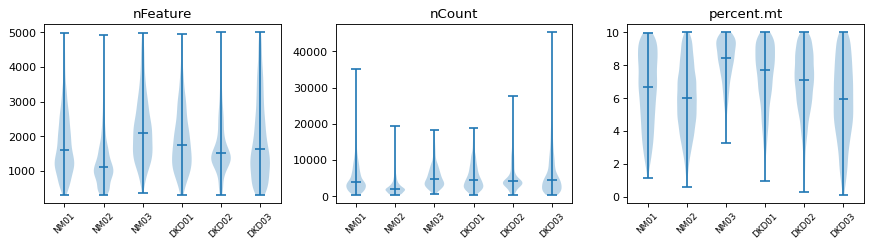

In [2]:
fig,ax=plt.subplots(1,3,figsize=(11,3.2))
for i,(lab,col) in enumerate([('nFeature',0),('nCount',1),('percent.mt',2)]):
    data=[QC[smp==s,col] for s,_ in samples]
    ax[i].violinplot(data, showmedians=True)
    ax[i].set_xticks(range(1,7)); ax[i].set_xticklabels([s for s,_ in samples],rotation=45,fontsize=8)
    ax[i].set_title(lab)
plt.tight_layout(); plt.show()


## 2. 정규화 + PCA
- **정규화**: 세포별 총량 보정(CPM) + log1p  
- **PCA**: 패널 유전자를 주성분으로 요약 (numpy SVD)


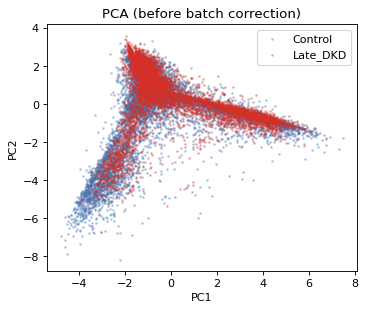

In [3]:
lib=QC[:,1:2].copy(); lib[lib==0]=1   # 라이브러리 크기 = 전체 유전자 총 count(nCount)
Xn=np.log1p(X/lib*1e4)                 # log-normalize (CPM+log)
Z=(Xn-Xn.mean(0))/(Xn.std(0)+1e-8)     # scale
U,S,Vt=np.linalg.svd(Z-Z.mean(0), full_matrices=False)
PC=U[:,:15]*S[:15]                       # 상위 15 PC
cols={'Control':'#4575b4','Late_DKD':'#d73027'}
plt.figure(figsize=(5,4))
for g in ['Control','Late_DKD']:
    m=grp==g; plt.scatter(PC[m,0],PC[m,1],s=2,alpha=.3,label=g,color=cols[g])
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (before batch correction)'); plt.legend(); plt.show()


## 3. 배치보정 (Harmony 대체: 샘플별 평균 제거)
6샘플 합치면 샘플별 차이(배치)가 생겨요. 진짜 Harmony 대신, **각 샘플의 PC 평균을 빼서** 배치를 대략 정렬합니다(간이 대체).


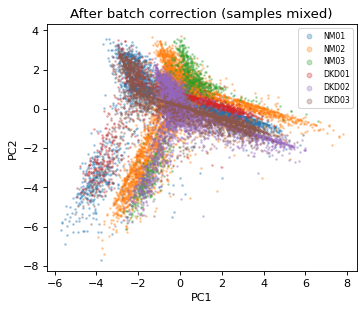

In [4]:
PCc=PC.copy()
for s,_ in samples:
    m=smp==s; PCc[m]-=PCc[m].mean(0)
plt.figure(figsize=(5,4))
for s,_ in samples:
    m=smp==s; plt.scatter(PCc[m,0],PCc[m,1],s=2,alpha=.3,label=s)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('After batch correction (samples mixed)')
plt.legend(markerscale=3,fontsize=7); plt.show()


## 4. 클러스터링 (KMeans) + 세포주석
비슷한 세포끼리 무리(KMeans, k=12). 각 무리를 **마커 유전자**로 판별해 세포타입을 붙입니다.  
마커: PCT(LRP2·CUBN·SLC34A1·ALDOB), 손상PCT/dPCT(VCAM1·HAVCR2·SPP1), EC(PECAM1·FLT1), T(CD3D), 대식(LYZ·CD68) 등


세포타입 분포: {np.str_('CD'): 392, np.str_('EC'): 2292, np.str_('dPCT'): 2684, np.str_('PCT'): 6263, np.str_('LOH-DCT'): 966, np.str_('Mono-Mac'): 1641, np.str_('T'): 3146, np.str_('MES'): 712, np.str_('Mast'): 230, np.str_('B'): 492}


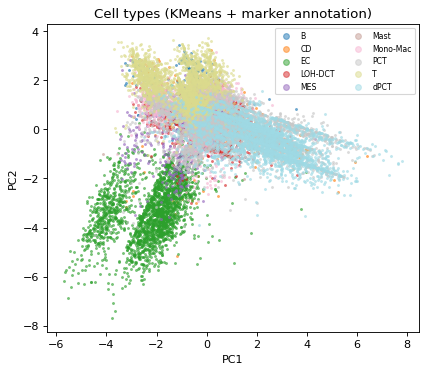

In [5]:
def kmeans(Xk,k,it=50):
    rng=np.random.default_rng(0); C=Xk[rng.choice(len(Xk),k,replace=False)]
    for _ in range(it):
        d=((Xk[:,None,:]-C[None])**2).sum(2); lab=d.argmin(1)
        for j in range(k):
            if (lab==j).any(): C[j]=Xk[lab==j].mean(0)
    return lab
K=12; lab=kmeans(PCc[:,:15],K)
# 마커→세포타입
mk={'PCT':['LRP2','CUBN','SLC34A1','ALDOB','GATM'],'dPCT':['VCAM1','HAVCR2','SPP1'],
    'EC':['PECAM1','FLT1','EMCN'],'MES':['PDGFRB','ITGA8'],'LOH-DCT':['UMOD','SLC12A1','SLC12A3'],
    'CD':['AQP2','SLC4A1'],'PODO':['NPHS1','NPHS2'],'T':['CD3D','CD3E'],'B':['CD79A','MS4A1'],
    'Mono-Mac':['LYZ','CD68','C1QA'],'Mast':['TPSAB1'],'Plasma':['MZB1']}
pidx={g:i for i,g in enumerate(panel)}
# 클러스터별 평균발현 → 마커 z-score → 세포타입 배정
cl_mean=np.array([Xn[lab==j].mean(0) for j in range(K)])
clz=(cl_mean-cl_mean.mean(0))/(cl_mean.std(0)+1e-8)
cl2ct={}
for j in range(K):
    best,bs=None,-1e9
    for ct,gs in mk.items():
        sc=np.mean([clz[j,pidx[g]] for g in gs if g in pidx])
        if sc>bs: bs,best=sc,ct
    cl2ct[j]=best
celltype=np.array([cl2ct[l] for l in lab])
# PCT를 손상마커(VCAM1/HAVCR2/SPP1)로 PCT/dPCT 세분 (논문 dPCT 정의)
inj=Xn[:,[pidx[g] for g in ['VCAM1','HAVCR2','SPP1'] if g in pidx]].mean(1)
pct_mask=celltype=='PCT'
if pct_mask.sum()>0:
    thr=np.quantile(inj[pct_mask],0.7); dmask=pct_mask&(inj>=thr); celltype[dmask]='dPCT'
import collections; print('세포타입 분포:', dict(collections.Counter(celltype)))
# 색으로 시각화
cts=sorted(set(celltype)); cmap=plt.cm.tab20(np.linspace(0,1,len(cts)))
plt.figure(figsize=(6,5))
for c,col in zip(cts,cmap):
    m=celltype==c; plt.scatter(PCc[m,0],PCc[m,1],s=3,alpha=.5,label=c,color=col)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Cell types (KMeans + marker annotation)')
plt.legend(markerscale=3,fontsize=7,ncol=2); plt.show()


## 5. ★ FN1·ALDH2 — 어느 세포에서, 어느 방향?
**논문 핵심(단계 의존)**
- 초기 DKD(Fig 6G, GSE131882): dPCT에서 **FN1↑**
- **말기 DKD(Fig 7G, GSE209781 = 우리 데이터): dPCT에서 FN1↓·ALDH2↓**

아래는 그룹·세포타입별 값이지만, **이 Python 근사의 FN1·ALDH2 수치는 신뢰용이 아닙니다.**
⭐ 정식 R 결과(권위 있음): **ALDH2↓ 재현 성공(p=3e-85), FN1은 검출한계 이하로 판정 불가.**
근사에서 FN1이 낮아 보이는 것은 패널·클러스터 잡음이며, ALDH2 dPCT가 높게 나오면 그것도 간이분할 오류입니다.


FN1: Control 0.482 → DKD 0.124  DKD↓(근사)  ※근사값·판정 근거 아님
ALDH2: Control 0.679 → DKD 0.649  DKD↓(근사)  ※근사값·판정 근거 아님

PCT  → FN1 0.086 / ALDH2 0.921
dPCT → FN1 0.038 / ALDH2 1.448
※ 근사값 — 방향 판정은 R 결과를 따르세요. 정식: 말기 dPCT ALDH2↓(p=3e-85) 재현, FN1은 검출한계 이하로 판정 불가.


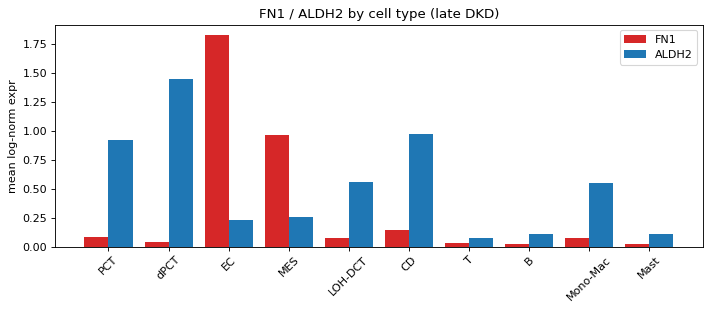

In [6]:
import numpy as np
# (a) 그룹 비교 — 논문 말기: FN1·ALDH2 둘 다 DKD에서 감소
for g in ['FN1','ALDH2']:
    c=Xn[grp=='Control',pidx[g]].mean(); d=Xn[grp=='Late_DKD',pidx[g]].mean()
    print(f'{g}: Control {c:.3f} → DKD {d:.3f}  {"DKD↓(근사)" if d<c else "DKD↑(근사)"}  ※근사값·판정 근거 아님')
# (b) 세포타입별 평균 — FN1은 EC/MES서도 높음(ECM 유전자)
order=[c for c in ['PCT','dPCT','EC','MES','LOH-DCT','CD','T','B','Mono-Mac','Mast','Plasma'] if c in set(celltype)]
fn1=[Xn[celltype==c,pidx['FN1']].mean() for c in order]
ald=[Xn[celltype==c,pidx['ALDH2']].mean() for c in order]
x=np.arange(len(order)); w=0.4
plt.figure(figsize=(9,4))
plt.bar(x-w/2,fn1,w,label='FN1',color='#d62728')
plt.bar(x+w/2,ald,w,label='ALDH2',color='#1f77b4')
plt.xticks(x,order,rotation=45); plt.ylabel('mean log-norm expr'); plt.legend()
plt.title('FN1 / ALDH2 by cell type (late DKD)'); plt.tight_layout(); plt.show()
if 'dPCT' in order:
    print(f"\nPCT  → FN1 {Xn[celltype=='PCT',pidx['FN1']].mean():.3f} / ALDH2 {Xn[celltype=='PCT',pidx['ALDH2']].mean():.3f}")
    print(f"dPCT → FN1 {Xn[celltype=='dPCT',pidx['FN1']].mean():.3f} / ALDH2 {Xn[celltype=='dPCT',pidx['ALDH2']].mean():.3f}")
    print('※ 근사값 — 방향 판정은 R 결과를 따르세요. 정식: 말기 dPCT ALDH2↓(p=3e-85) 재현, FN1은 검출한계 이하로 판정 불가.')


## 6. 세포비율 (Control vs 말기 DKD)
손상 근위세관(dPCT) 비율이 말기 DKD에서 늘어나는지.


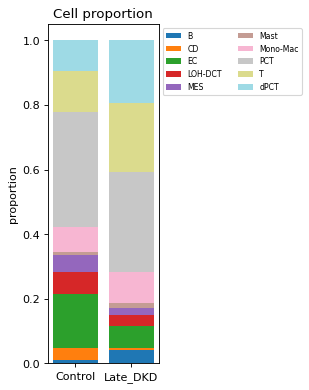

In [7]:
cts2=sorted(set(celltype))
prop={}
for g in ['Control','Late_DKD']:
    sub=celltype[grp==g]; prop[g]=[np.mean(sub==c) for c in cts2]
x=np.arange(2); bottom=np.zeros(2); cmap=plt.cm.tab20(np.linspace(0,1,len(cts2)))
plt.figure(figsize=(4,5))
for i,c in enumerate(cts2):
    vals=[prop['Control'][i],prop['Late_DKD'][i]]
    plt.bar(x,vals,bottom=bottom,label=c,color=cmap[i]); bottom+=vals
plt.xticks(x,['Control','Late_DKD']); plt.ylabel('proportion')
plt.legend(fontsize=7,ncol=2,bbox_to_anchor=(1,1)); plt.title('Cell proportion'); plt.tight_layout(); plt.show()


## 7. 유사시간 (pseudotime 대체: 손상점수 정렬)
monocle 대신, PCT+dPCT 세포를 **손상 마커 점수**로 정렬(정상→손상)해 FN1 변화를 봅니다.  
말기 DKD(Fig 7G)에선 손상이 진행될수록 **FN1이 감소**하는 게 논문 방향.


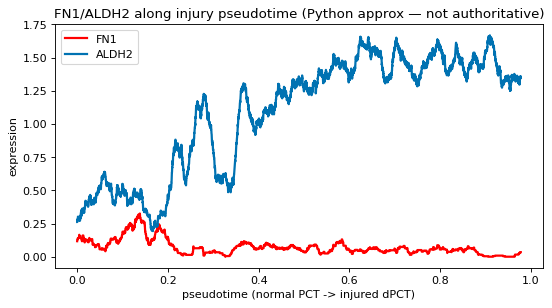

In [8]:
sel=np.isin(celltype,['PCT','dPCT'])
inj=Xn[sel][:,[pidx[g] for g in ['VCAM1','HAVCR2','SPP1'] if g in pidx]].mean(1)  # 손상점수
o=np.argsort(inj)                       # 정상→손상 정렬 = 유사시간
pt=np.linspace(0,1,sel.sum())
fn1=Xn[sel][o,pidx['FN1']]; ald=Xn[sel][o,pidx['ALDH2']]
def smooth(y,w=200): return np.convolve(y,np.ones(w)/w,mode='valid')
plt.figure(figsize=(7,4))
plt.plot(pt[:len(smooth(fn1))],smooth(fn1),color='red',label='FN1',lw=2)
plt.plot(pt[:len(smooth(ald))],smooth(ald),color='#0072B2',label='ALDH2',lw=2)
plt.xlabel('pseudotime (normal PCT -> injured dPCT)'); plt.ylabel('expression'); plt.legend()
plt.title('FN1/ALDH2 along injury pseudotime (Python approx — not authoritative)'); plt.tight_layout(); plt.show()


## 8. 정리 (정직 버전)
- 실제 GSE209781 데이터로 QC → **총 18,818 세포** (논문 18,816과 거의 일치) ✅ — 이 부분은 신뢰 가능.
- **FN1·ALDH2 방향은 이 Python 근사로 판정하지 않습니다.** 32유전자 패널 + 간이 KMeans라 잡음이 큼.

⭐ **정식·최종 결과 = R 파이프라인(`06_scrna/*.R`, 플랫폼 교락 제거 05 포함):**
- ✅ **말기 dPCT에서 ALDH2↓ 재현** (PCT 1.75 → dPCT 1.27, wilcox p=3e-85 · Fig 7G)
- ⚠ **FN1은 세뇨관 단일핵(snRNA)에서 검출한계 이하** → 초기 dPCT FN1↑(Fig 6G)도 말기 dPCT FN1↓(Fig 7G)도 확인 불가. ECM 유전자 저포집이라는 **데이터 한계**이며, 억지로 맞추지 않고 정직 보고.

**교훈**: 이 노트북은 파이프라인 '흐름 이해용' 근사. 방향·유의성 결론은 반드시 R을 근거로.
